<a href="https://colab.research.google.com/github/bw123111/MLcourse2025/blob/main/assignments/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 - Probability, Linear Algebra, & Computational Programming

## Bella Wengappuly
Netid: bw165311

*Names of students you worked with on this assignment*:
Tara Brown
___

Note: this assignment falls under collaboration Mode 2: Individual Assignment – Collaboration Permitted. Please refer to the syllabus on Canvas for additional information.

Instructions for all assignments can be found [here](https://github.com/kylebradbury/ids705/blob/master/assignments/_Assignment%20Instructions.ipynb), and is also linked to from the [course syllabus](https://kylebradbury.github.io/ids705/index.html).

Total points in the assignment add up to 90; an additional 10 points are allocated to presentation quality.

#  Learning Objectives
The purpose of this assignment is to provide a refresher on fundamental concepts that we will use throughout this course, and provide an opportunity to develop skills in any of the related skills that may be unfamiliar to you. Through the course of completing this assignment, you will...
- Refresh you knowledge of probability theory including properties of random variables, probability density functions,  cumulative distribution functions, and key statistics such as mean and variance.
- Revisit common linear algebra and matrix operations and concepts such as matrix multiplication, inner and outer products, inverses, the Hadamard (element-wise) product, eigenvalues and eigenvectors, orthogonality, and symmetry.
- Practice numerical programming, core to machine learning, by loading and filtering data, plotting data, vectorizing operations, profiling code speed, and debugging and optimizing performance. You will also practice computing probabilities based on simulation.
- Develop or refresh your knowledge of Git version control, which will be a core tool used in the final project of this course
- Apply your skills altogether through an exploratory data analysis to practice data cleaning, data manipulation, interpretation, and communication

We will build on these concepts throughout the course, so use this assignment as a catalyst to deepen your knowledge and seek help with anything that is unfamiliar.

Just know... this is supposed to be a hard assignment!  Try your best and allow for enough time to finish.

# Probability and Statistics Theory

*Note: for all assignments, write out all equations and math using markdown and [LaTeX](https://tobi.oetiker.ch/lshort/lshort.pdf). For this assignment show ALL math work*

## 1
**[3 points]**  
Let $f(x) = \begin{cases}
                0           & x < 0  \\
                \alpha x^2  & 0 \leq x \leq 2 \\
                0           & 2 < x
            \end{cases}$
            
For what value of $\alpha$ is $f(x)$ a valid probability density function?

PDF must equal 1 over all x. F(x) > 0 only for values of x between 0 and 2. Set derivative of f(x) as equal to 1 and solve for alpha.

\begin{align*}\\
1 = \int_{0}^{2} αx^2 = α\bigg|_{0}^{2} \frac{x^3}{3} = α\frac{8}{3} \\\\
α=\frac{3}{8}
\end{align*}


## 2
**[3 points]** What is the cumulative distribution function (CDF) that corresponds to the following probability distribution function? Please state the value of the CDF for all possible values of $x$.

$f(x) = \begin{cases}
    \frac{1}{3} & 0 < x < 3 \\
    0           & \text{otherwise}
    \end{cases}$

Math work for 0<x<3:
\begin{align*}
CDF = F(x) = \int_{0}^{3} \frac{1}{3} dx = \frac{x}{3} \\\\
F(x) =
\begin{cases}
0, & x \leq 0, \\
\dfrac{x}{3}, & 0 < x < 3, \\
1, & x \geq 3.
\end{cases}
\end{align*}



## 3
**[6 points]** For the probability distribution function for the random variable $X$,

\begin{align*}
f(x) &=
\begin{cases}
\dfrac{1}{3}, & 0 < x < 3, \\
0, &
\text{otherwise}.
\end{cases}
\end{align*}
    
what is the (a) expected value and (b) variance of $X$. *Show all work*.

\begin{align*}
\\[1em]
E[X] &=
\int_{0}^{3} x \cdot \tfrac{1}{3}\,dx
= \tfrac{1}{3}\left[\tfrac{x^{2}}{2}\right]_{0}^{3}
= \tfrac{9}{6}
= \tfrac{3}{2}, \\[1em]
E[X^{2}] &= \int_{0}^{3} x^{2}\cdot\tfrac{1}{3}\,dx
= \tfrac{1}{3}\left[\tfrac{x^{3}}{3}\right]_{0}^{3}
= 3, \\[1em]
\operatorname{Var}(X) &= E[X^{2}] - (E[X])^{2}
= 3 - \left(\tfrac{3}{2}\right)^{2}
= \tfrac{3}{4}.
\end{align*}


In [2]:
# calculations in code since I got curious about how to do it this way...
# it produced the same values as what I derived by hand!
import sympy as sp

# Random var X
x = sp.Symbol('x')

# PDF for Uniform(0,3)
f = 1/3  # valid only on 0 < x < 3

# Expected value integral calculation
E_X = sp.integrate(x * f, (x, 0, 3))

# Expected value of X^2 using integral calculation
E_X2 = sp.integrate((x**2) * f, (x, 0, 3))

# Variance calculation using expected value subtracted from expected value squared.
Var_X = E_X2 - E_X**2

print(f"Expected Value (E[X]): {E_X:.2f}")
print(f"Variance (Var[X]): {Var_X:.2f}")

Expected Value (E[X]): 1.50
Variance (Var[X]): 0.75


## 4
**[6 points]** Consider the following table of data that provides the values of a discrete data vector $\mathbf{x}$ of samples from the random variable $X$, where each entry in $\mathbf{x}$ is given as $x_i$.

*Table 1. Dataset N=5 observations*

|        | $x_0$ | $x_1$ | $x_2$ | $x_3$ | $x_4$ |
|------  |-------|-------|-------|-------|-------|
|$\textbf{x}$| 2     | 3     | 10    | -1    | -1    |

What is the (a) mean and (b) variance of the data?

*Show all work. Your answer should include the definition of mean and variance in the context of discrete data. In this case, use the sample variance since the sample size is quite small*

\begin{equation}
mean = \mu = E(X) = \sum_{i}^{n} x_i *P(X=x_i) = \frac{1}{n} \sum_{i}^{n} x_i \\\\var = σ^{2} = E[(X - \mu)^2] = \frac{1}{n-1} \sum_{i}^{n} (x_i-\mu)^2
\end{equation}



In [3]:
data = [2,3,10,-1,-1]
px = 1/5
px_var = 1/4
mu = px*(sum(data))
var = px_var*(sum((x-mu)**2 for x in data))
print("mean:", mu, "\nsample variance:", var)

mean: 2.6 
sample variance: 20.3


# Linear Algebra

## 5
**[14 points]** **Matrix manipulations and multiplication**. Machine learning involves working with many matrices, so this exercise will provide you with the opportunity to practice those skills.

Let
$\mathbf{A} =  \begin{bmatrix}
1 & 2 & 3 \\
2 & 4 & 5 \\
3 & 5 & 6
\end{bmatrix}$, $\mathbf{b} =  \begin{bmatrix}
-1  \\
3  \\
8  
\end{bmatrix}$, $\mathbf{c} =  \begin{bmatrix}
4  \\
-3  \\
6  
\end{bmatrix}$, and $\mathbf{I} =  \begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}$

Compute the following (using Python) or indicate that it cannot be computed. Refer to numpy's tools for handling matrices.

1. $\mathbf{A}\mathbf{A}$
2. $\mathbf{A}\mathbf{A}^T$
3. $\mathbf{A}\mathbf{b}$
4. $\mathbf{A}\mathbf{b}^T$
5. $\mathbf{b}\mathbf{A}$
6. $\mathbf{b}^T\mathbf{A}$
7. $\mathbf{b}\mathbf{b}$
8. $\mathbf{b}^T\mathbf{b}$
9. $\mathbf{b}\mathbf{b}^T$
10. $\mathbf{b} + \mathbf{c}^T$
11. $\mathbf{b}^T\mathbf{b}^T$
12. $\mathbf{A}^{-1}\mathbf{b}$
13. $\mathbf{A}\circ\mathbf{A}$
14. $\mathbf{b}\circ\mathbf{c}$

*Note: The element-wise (or Hadamard) product is the product of each element in one matrix with the corresponding element in another matrix, and is represented by the symbol "$\circ$".*

Set up problem:

In [4]:
import numpy as np

A = [[1,2,3],[2,4,5],[3,5,6]]
b = [[-1],[3],[8]]
c = [[4],[-3],[6]]
I = np.identity(3)

At = np.transpose(A)
bt = np.transpose(b)
ct = np.transpose(c)

# function to calculate matrix function if possible and return "cannot be computed" if
# an error is thrown.
def calc(q_num,func,x,y):
  try:
    product = func(x,y)
  except ValueError:
    product = "cannot be computed"
  print(q_num, ":\n", product, "\n")

In [5]:
# arrays for a and b of matrix multiplication for questions 1-9. 10-14 done by hand/written out.
matrixa = [A,A,A,A,b,bt,b,bt,b,b,bt,np.linalg.inv(A),A,b]
matrixb = [A,At,b,bt,A,A,b,b,bt,ct,bt,b,A,c]

# compute dot product of questions 1-9, 11-12. sum for #10, multiply for 13,14.
for i in range(len(matrixa)):
  if i+1 == 13 or i+1 == 14:     # element-wise multiply if question 13 or 14
    calc(i+1, np.multiply, matrixa[i], matrixb[i])
  elif i+1 == 10:                 # addition
    try:
      product = matrixa[i] + matrixb[i]
    except ValueError:
      product = "cannot be computed"
    print(i+1, ":\n", product, "\n")
  else:                           # dot product
    calc(i+1, np.dot, matrixa[i], matrixb[i])


1 :
 [[14 25 31]
 [25 45 56]
 [31 56 70]] 

2 :
 [[14 25 31]
 [25 45 56]
 [31 56 70]] 

3 :
 [[29]
 [50]
 [60]] 

4 :
 cannot be computed 

5 :
 cannot be computed 

6 :
 [[29 50 60]] 

7 :
 cannot be computed 

8 :
 [[74]] 

9 :
 [[ 1 -3 -8]
 [-3  9 24]
 [-8 24 64]] 

10 :
 [[ 3 -4  5]
 [ 7  0  9]
 [12  5 14]] 

11 :
 cannot be computed 

12 :
 [[ 6.]
 [ 4.]
 [-5.]] 

13 :
 [[ 1  4  9]
 [ 4 16 25]
 [ 9 25 36]] 

14 :
 [[-4]
 [-9]
 [48]] 



## 6
**[8 points]** **Eigenvectors and eigenvalues**. Eigenvectors and eigenvalues are useful for some machine learning algorithms, but the concepts take time to solidly grasp. They are used extensively in machine learning and in this course we will encounter them in relation to Principal Components Analysis (PCA), clustering algorithms, For an intuitive review of these concepts, explore this [interactive website at Setosa.io](http://setosa.io/ev/eigenvectors-and-eigenvalues/). Also, the series of linear algebra videos by Grant Sanderson of 3Brown1Blue are excellent and can be viewed on youtube [here](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab). For these questions, numpy may once again be helpful.

1. Calculate the eigenvalues and corresponding eigenvectors of matrix $\mathbf{A}$ above, from the last question.
2. Choose one of the eigenvector/eigenvalue pairs, $\mathbf{v}$ and $\lambda$, and show that $\mathbf{A} \mathbf{v} = \lambda \mathbf{v}$. This relationship extends to higher orders: $\mathbf{A} \mathbf{A} \mathbf{v} = \lambda^2 \mathbf{v}$
3. Show that the eigenvectors are orthogonal to one another (e.g. their inner product is zero). This is true for eigenvectors from real, symmetric matrices. In three dimensions or less, this means that the eigenvectors are perpendicular to each other. Typically we use the orthogonal basis of our standard x, y, and z, Cartesian coordinates, which allows us, if we combine them linearly, to represent any point in a 3D space. But any three orthogonal vectors can do the same. We will see this property is used in PCA to identify the dimensions of greatest variation in our data when we discuss dimensionality reduction.

I used [scriptverse](https://scriptverse.academy/tutorials/python-eigenvalues-eigenvectors.html) as a resource to understand numpy's eig functions.

### Answer to 6.1

In [6]:
evalue, evect = np.linalg.eig(A)
print("eigenvalues of A:\n", evalue, "\n\neigenvectors of A:\n", evect)

eigenvalues of A:
 [11.34481428 -0.51572947  0.17091519] 

eigenvectors of A:
 [[-0.32798528 -0.73697623  0.59100905]
 [-0.59100905 -0.32798528 -0.73697623]
 [-0.73697623  0.59100905  0.32798528]]


### Answer to 6.2

In [7]:
# grab the first eigenvalue and the first column from the evect matrix to get the
# corresponding first eigenvalue and eigenvector.
v = evect[:,0]  #eigenvector
lamb = evalue[0]  #eigenvalue

print("eigenvector of A\n", v, "\n\neigenvalue of A\n", lamb, "\n")

print("Av =", np.dot(A,v))
print("lambda v =", np.dot(lamb,v))
# do both matrices match each other?
# np.allclose Returns True if two arrays are element-wise equal within a tolerance.
print("\nAv = lambda v:", np.allclose(np.dot(A,v),(np.dot(lamb,v))))


eigenvector of A
 [-0.32798528 -0.59100905 -0.73697623] 

eigenvalue of A
 11.344814282762083 

Av = [-3.72093206 -6.70488789 -8.36085845]
lambda v = [-3.72093206 -6.70488789 -8.36085845]

Av = lambda v: True


### Answer to 6.3
2 matrices are orthogonal if their inner product (can use dot product) is zero.

In [8]:
print(f"dot product eigenvectors 0 and 1: {np.dot(evect[:,0], evect[:,1]):.4f}")
print(f"dot product eigenvectors 0 and 2: {np.dot(evect[:,0], evect[:,2]):.4f}")
print(f"dot product eigenvectors 1 and 2: {np.dot(evect[:,1], evect[:,2]):.4f}")

print("all dot products above are equal:",np.allclose(np.dot(evect[:,0], evect[:,1]),np.dot(evect[:,0], evect[:,2]),np.dot(evect[:,1], evect[:,2])))

dot product eigenvectors 0 and 1: -0.0000
dot product eigenvectors 0 and 2: -0.0000
dot product eigenvectors 1 and 2: -0.0000
all dot products above are equal: True


All the dot products above are equal to each other and zero. This indicates that the eigenvectors are orthogonal to each other.

# Numerical Programming

## 7
**[10 points]** Loading data and gathering insights from a real dataset

In data science, we often need to have a sense of the idiosyncrasies of the data, how they relate to the questions we are trying to answer, and to use that information to help us to determine what approach, such as machine learning, we may need to apply to achieve our goal. This exercise provides practice in exploring a dataset and answering question that might arise from applications related to the data.

**Data**. The data for this problem can be found in the `data` subfolder in the `assignments` folder on [github](https://github.com/kylebradbury/ids705). The filename is `a1_egrid2016.xlsx`. This dataset is the Environmental Protection Agency's (EPA) [Emissions & Generation Resource Integrated Database (eGRID)](https://www.epa.gov/energy/emissions-generation-resource-integrated-database-egrid) containing information about all power plants in the United States, the amount of generation they produce, what fuel they use, the location of the plant, and many more quantities. We'll be using a subset of those data.

The fields we'll be using include:
    
|field    |description|
|:-----   |:-----|
|SEQPLT16 |eGRID2016 Plant file sequence number (the index)|
|PSTATABB |Plant state abbreviation|
|PNAME    |Plant name |
|LAT      |Plant latitude |
|LON      |Plant longitude|
|PLPRMFL  |Plant primary fuel |
|CAPFAC   |Plant capacity factor |
|NAMEPCAP |Plant nameplate capacity (Megawatts MW)|
|PLNGENAN |Plant annual net generation (Megawatt-hours MWh)|
|PLCO2EQA |Plant annual CO2 equivalent emissions (tons)|

For more details on the data, you can refer to the [eGrid technical documents](https://www.epa.gov/sites/default/files/2021-02/documents/egrid2019_technical_guide.pdf). For example, you may want to review page 45 and the section "Plant Primary Fuel (PLPRMFL)", which gives the full names of the fuel types including WND for wind, NG for natural gas, BIT for Bituminous coal, etc.

There also are a couple of "gotchas" to watch out for with this dataset:
- The headers are on the second row and you'll want to ignore the first row (they're more detailed descriptions of the headers).
- NaN values represent blanks in the data. These will appear regularly in real-world data, so getting experience working with it will be important.

**Your objective**. For this dataset, your goal is answer the following questions about electricity generation in the United States:

**(a)** Which plant has generated the most energy (measured in MWh)?

**(b)** What is the name of the northern-most power plant in the United States?

**(c)** What is the state where the northern-most power plant in the United States is located?

**(d)** Plot a bar plot showing the amount of energy produced by each fuel type across all plants.

**(e)** From the plot in (d), which fuel for generation produces the most energy (MWh) in the United States?

In [9]:
import pandas as pd

# url to RAW document path in my github clone of the course.
# Must change "blob" in web address to "raw" for this to work!!
url = "https://github.com/bw123111/MLcourse2025/raw/main/assignments/data/a1_egrid2016.xlsx"

# import data as dataframe, specify engine or else this will not work!!
# skip importing the first row of detailed headers.
data = pd.read_excel(url, engine="openpyxl", skiprows=1)

print(data.columns)
data.head()

Index(['SEQPLT16', 'PSTATABB', 'PNAME', 'LAT', 'LON', 'PLPRMFL', 'CAPFAC',
       'NAMEPCAP', 'PLNGENAN', 'PLCO2EQA'],
      dtype='object')


,SEQPLT16,PSTATABB,PNAME,LAT,LON,PLPRMFL,CAPFAC,NAMEPCAP,PLNGENAN,PLCO2EQA
0,1,AK,7-Mile Ridge Wind Project,63.210689,-143.247156,WND,NaN,1.8,NaN,NaN
1,2,AK,Agrium Kenai Nitrogen Operations,60.673200,-151.378400,NG,NaN,21.6,NaN,NaN
2,3,AK,Alakanuk,62.683300,-164.654400,DFO,0.05326,2.6,1213.001,1049.863
3,4,AK,Allison Creek Hydro,61.084444,-146.353333,WAT,0.01547,6.5,881.000,0.000
4,5,AK,Ambler,67.087980,-157.856719,DFO,0.13657,1.1,1315.999,1087.881


## Answer 7a

In [10]:
print(data[data.PLNGENAN == (data['PLNGENAN'].max())].PNAME.values[0], "plant generated the most energy at", data[data.PLNGENAN == (data['PLNGENAN'].max())].PLNGENAN.values[0], "MWh.")

Palo Verde plant generated the most energy at 32377476.999 MWh.


## Answer 7b

In [11]:
print(data[data.LAT == data.LAT.max()].PNAME.values[0], "is the northern-most power plant in the United States.")

Barrow is the northern-most power plant in the United States.


## Answer 7c

In [12]:
print(data[data.LAT == data.LAT.max()].PSTATABB.values[0], "is the state with the northern-most power plant in the United States.")

AK is the state with the northern-most power plant in the United States.


## Answer 7d

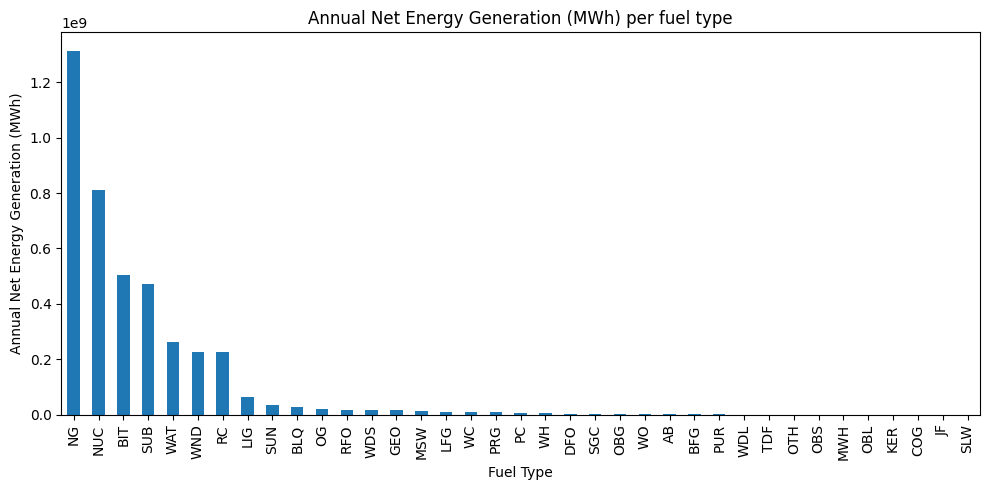

In [13]:
import matplotlib.pyplot as plt

fuel_totals = pd.DataFrame(data.groupby('PLPRMFL').PLNGENAN.sum())
fuel_totals = fuel_totals.sort_values(by="PLNGENAN", ascending=False)

# fuel_totals.head()
fuel_totals.plot(kind='bar', legend=False, figsize=(10,5))
plt.title("Annual Net Energy Generation (MWh) per fuel type")
plt.xlabel("Fuel Type")
plt.ylabel("Annual Net Energy Generation (MWh)")
plt.tight_layout()
plt.show()

## Answer 7e
Natural Gas plants have the greatest net energy generation annually.

## 8
**[6 points]** *Vectorization*. When we first learn to code and think about iterating over an array, we often use loops. If implemented correctly, that does the trick. In machine learning, we iterate over so much data that those loops can lead to significant slow downs if they are not computationally efficient. In Python, vectorizing code and relying on matrix operations with efficient tools like numpy is typically the faster approach. Of course, numpy relies on loops to complete the computation, but this is at a lower level of programming (typically in C), and therefore is much more efficient. This exercise will explore the benefits of vectorization. Since many machine learning techniques rely on matrix operations, it's helpful to begin thinking about implementing algorithms using vector forms.

Begin by creating an array of 1 million random numbers using the numpy `random.randn` module. Compute the sum of the squares of those random numbers first in a for loop, then using Numpy's `dot` module to perform an inner (dot) product. Time how long it takes to compute each and report the results and report the output. How many times faster is the vectorized code than the for loop approach? (Note - your results may vary from run to run).

Your output should use the `print()` function as follows (where the # symbols represent your answers, to a reasonable precision of 4-5 significant figures):

`Time [sec] (non-vectorized): ######`

`Time [sec] (vectorized):     ######`

`The vectorized code is ##### times faster than the nonvectorized code`

In [14]:
import time

# create array of 1 million random numbers
nums = np.random.randn(1000000)
loop_sum = 0

start = time.time()
for num in nums:
  loop_sum += num**2
print(f"Loop sum is {loop_sum:.4f}")
end = time.time()
elapsed_loop = end - start

start = time.time()
vec_sum = np.dot(nums,nums)
print(f"Vector sum is {vec_sum:.4f}")
end = time.time()
elapsed_vec = end - start

print(f"Time [sec] (non-vectorized): {elapsed_loop:.4f}")
print(f"Time [sec] (vectorized): {elapsed_vec:.4f}")
print(f"The vectorized code is {elapsed_loop/elapsed_vec:.4f} times faster than the nonvectorized code.")


Loop sum is 999783.8366
Vector sum is 999783.8366
Time [sec] (non-vectorized): 0.3582
Time [sec] (vectorized): 0.0010
The vectorized code is 355.1307 times faster than the nonvectorized code.


**ANSWER**

## 9
**[10 points]** This exercise will walk through some basic numerical programming and probabilistic thinking exercises, two skills which are frequently use in machine learning for answering questions from our data.
1. Synthesize $n=10^4$ normally distributed data points with mean $\mu=2$ and a standard deviation of $\sigma=1$. Call these observations from a random variable $X$, and call the vector of observations that you generate, $\textbf{x}$.
2. Calculate the mean and standard deviation of $\textbf{x}$ to validate (1) and provide the result to a precision of four significant figures.
3. Plot a histogram of the data in $\textbf{x}$ with 30 bins
4. What is the 90th percentile of $\textbf{x}$? The 90th percentile is the value below which 90% of observations can be found.
5. What is the 99th percentile of $\textbf{x}$?
6. Now synthesize $n=10^4$ normally distributed data points with mean $\mu=0$ and a standard deviation of $\sigma=3$. Call these observations from a random variable $Y$, and call the vector of observations that you generate, $\textbf{y}$.
7. Create a new figure and plot the histogram of the data in $\textbf{y}$ on the same axes with the histogram of $\textbf{x}$, so that both histograms can be seen and compared.
8. Using the observations from $\textbf{x}$ and $\textbf{y}$, estimate $E[XY]$

mean of x: 2.0004
standard deviation of x: 0.9868


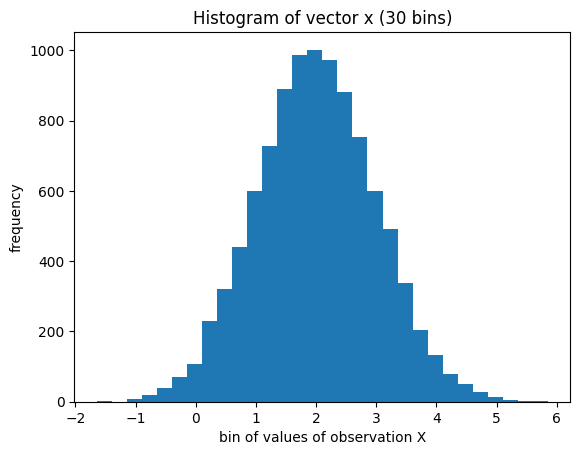

In [15]:
x = np.random.normal(size = 10000, loc=2, scale=1)    # loc = mean, scale = sd
x_mean = np.mean(x)
x_sd = np.std(x)
print(f"mean of x: {x_mean:.4f}")
print(f"standard deviation of x: {x_sd:.4f}")

plt.hist(x, bins=30)
plt.ylabel("frequency")
plt.xlabel("bin of values of observation X")
plt.title("Histogram of vector x (30 bins)")
plt.show()

In [16]:
q90 = np.percentile(x, 9)
q99 = np.percentile(x, 99)
print(f"90th percentile of x: {q90:.4f}")
print(f"99th percentile of x: {q99:.4f}")

90th percentile of x: 0.6795
99th percentile of x: 4.3480


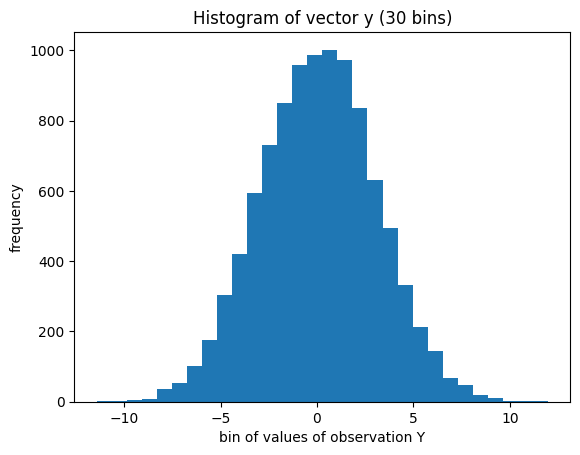

In [17]:
y = np.random.normal(size = 10000, loc=0, scale=3)    # loc = mean, scale = sd
plt.hist(y, bins=30)
plt.ylabel("frequency")
plt.xlabel("bin of values of observation Y")
plt.title("Histogram of vector y (30 bins)")
plt.show()

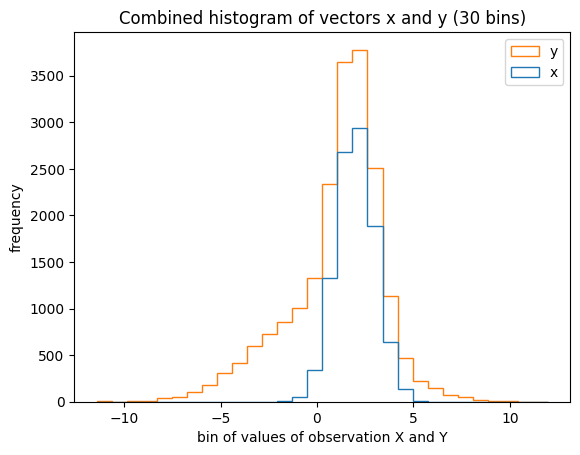

In [18]:
# combined plot
xy = [x,y]
plt.hist(xy, bins=30, histtype="step", stacked=True, fill=False, label=["x","y"])   # hist settings
plt.ylabel("frequency")
plt.xlabel("bin of values of observation X and Y")
plt.title("Combined histogram of vectors x and y (30 bins)")
plt.legend()
plt.show()

E[XY] for 2 independent continuous normal distributions is E[X]*E[Y]

In [19]:
E_xy = np.mean(x)*np.mean(y)
print(f"E[XY] = {E_xy:.4f}")

E[XY] = 0.1445


# Version Control via Git

## 10
**[4 points]** Git is efficient for collaboration, and expectation in industry, and one of the best ways to share results in academia. You can even use some Git repositories (e.g. Github) as hosts for website, such as with the [course website](https://kylebradbury.github.io/ids705/index.html). As a data scientist with experience in machine learning, Git is expected. We will interact with Git repositories (a.k.a. repos) throughout this course, and your project will require the use of git repos for collaboration.

Complete the [Atlassian Git tutorial](https://www.atlassian.com/git/tutorials/what-is-version-control), specifically the following listed sections. Try each concept that's presented. For this tutorial, instead of using BitBucket as your remote repository host, you may use your preferred platform such as [Github](https://github.com/) or [Duke's Gitlab](https://gitlab.oit.duke.edu/users/sign_in).
1. [What is version control](https://www.atlassian.com/git/tutorials/what-is-version-control)
2. [What is Git](https://www.atlassian.com/git/tutorials/what-is-git)
3. [Install Git](https://www.atlassian.com/git/tutorials/install-git)
4. [Setting up a repository](https://www.atlassian.com/git/tutorials/install-git)
5. [Saving changes](https://www.atlassian.com/git/tutorials/saving-changes)
6. [Inspecting a repository](https://www.atlassian.com/git/tutorials/inspecting-a-repository)
7. [Undoing changes](https://www.atlassian.com/git/tutorials/undoing-changes)
8. [Rewriting history](https://www.atlassian.com/git/tutorials/rewriting-history)
9. [Syncing](https://www.atlassian.com/git/tutorials/syncing)
10. [Making a pull request](https://www.atlassian.com/git/tutorials/making-a-pull-request)
11. [Using branches](https://www.atlassian.com/git/tutorials/using-branches)
12. [Comparing workflows](https://www.atlassian.com/git/tutorials/comparing-workflows)

I also have created two videos on the topic to help you understand some of these concepts: [Git basics](https://www.youtube.com/watch?v=fBCwfoBr2ng) and a [step-by-step tutorial](https://www.youtube.com/watch?v=nH7qJHx-h5s).

For your answer, affirm that you *either* completed the tutorials above OR have previous experience with ALL of the concepts above. Confirm this by typing your name below and selecting the situation that applies from the two options in brackets.

**ANSWER**

*I, [**your name here**], affirm that I have [**completed the above tutorial / I have previous experience that covers all the content in this tutorial**]*

# Exploratory Data Analysis
## 11
**[20 points]** Here you'll bring together some of the individual skills that you demonstrated above and create a Jupyter notebook based blog post on your exploratory data analysis. Your goal is to identify a question or problem and to work towards solving it or providing additional information or evidence (data) related to it through your data analysis. Below, we walk through a process to follow for your analysis. Additionally, you can find an [example of a well-done exploratory data analysis here from past years](https://github.com/kylebradbury/ids705/blob/master/assignments/Assignment_1_Q11_Example.ipynb).

1. Find a dataset that interests you and relates to a question or problem that you find intriguing.
2. Describe the dataset, the source of the data, and the reason the dataset was of interest. What question are you hoping to answer through exploring the dataset?
3. Check the data and see if they need to be cleaned: are there missing values? Are there clearly erroneous values? Do two tables need to be merged together? Clean the data so it can be visualized. If the data are clean, state how you know they are clean (what did you check?).
3. Plot the data, demonstrating interesting features that you discover. Are there any relationships between variables that were surprising or patterns that emerged? Please exercise creativity and curiosity in your plots. You should have at least a ~3 plots exploring the data in different ways.
4. What insights are you able to take away from exploring the data? Is there a reason why analyzing the dataset you chose is particularly interesting or important? Summarize this for a general audience (imagine your publishing a blog post online) - boil down your findings in a way that is accessible, but still accurate.

Here your analysis will evaluated based on:
1. Motivation: was the purpose of the choice of data clearly articulated? Why was the dataset chosen and what was the goal of the analysis?
2. Data cleaning: were any issues with the data investigated and, if found, were they resolved?
3. Quality of data exploration: were at least 4 unique plots (minimum) included and did those plots demonstrate interesting aspects of the data? Was there a clear purpose and takeaway from EACH plot?
4. Interpretation: Were the insights revealed through the analysis and their potential implications clearly explained? Was there an overall conclusion to the analysis?

**ANSWER**
# Identifying Montanan Wolverines

Wolverines are listed as threatened under the United States Endangered Species Act in 2023. The largest terrestrial member of the weasel family, these animals thrive in large, continous, snowy alpine habitats. The mean home range of a Montana wolverine is around 160 square miles, according to the Montana Field Guide. Female wolverines require deep snow (at least 5 feet) that persists through May to den in and raise their kits. These factors make locating wolverines and wolverine dens difficult and dangerous.

Bait stations are often used to monitor medium-sized carnivores in remote areas, decreasing the amount of field hours and habitat disturbance required compared to ground surveys. The bait stations used to collect the following data used a vertical ladder frame with meat hanging from above to incentivize animals to expose their ventral area. A motion-sensor camera trap would capture the animal's underside as it interacted with the bait station. Animals such as wolverine, lynx, and pine martens have unique ventral fur patterns that can be used to identify unique individuals that visited the bait station.

A record of unique individual animals can be used to estimate population size and density, which is used to inform management decisions and policy-making. Den locations are essential to maximizing management actions for the least time, as protecting natal dens from disturbance (by recreationists, for example) during a few winter months is much easier and cheaper than protecting entire mountains year-round.

The following dataset documents detection events for animals at various bait stations set up in Montana National Forests between 2016 and 2022. Some of the data fields include: detected species, detected individual, year detected, station name, survey cell, detection duration, number of photos, and detection start/end times. I am using this data as part of my undergraduate thesis, which has **three objectives:**

1.   Assess the feasibility and performance of employing existing machine learning tools to identify individual wolverines from camera trap images using unique pelage patterns.
2.   Identify high detectability areas for wolverines in the survey areas using statistical models to guide population surveys.
3.   Utilize drones to non-invasively, ethically, and safely detect wolverine natal dens.

The data needs to be processed to focus on individual wolverines, where they were detected, and how much they visited each bait station. An understanding of where and when each bait station was operated is also essential so that this information can be used in combination with other environmental data to run an advanced statistical model predicting high detectability areas for each individual wolverine. Prior years' data can be used to inform current efforts because wolverines tend to maintain roughly the same territory location and area each year. In addition, some counts of how many photos/detections were made of each individual would be useful for performance testing existing machine learning tools.

In [21]:
# set up and data import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# temporarily imported data to google colab environment, then read it in
filepath = '/Detection inventory.xlsx'
data = pd.read_excel(filepath)

# data exploration
data.head()

,Detection event,Linked Individual,Linked Individual II,Linked individual III,Linked individual IV,Linked individual V,Linked individual VI,Year,Zone,Cell,...,Genetic sample 91,Genetic sample 92,Genetic sample 93,Genetic sample 94,Genetic sample 95,Genetic sample 96,Genetic sample 97,Genetic sample 98,Genetic sample 99,Genetic sample 100
0,1-Bobcat-2016-MC,BOBC-MC1-2016,NaN,NaN,NaN,NaN,NaN,2016,1.0,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1-Bobcat-2016-OM,BOBC-OM1-2016,NaN,NaN,NaN,NaN,NaN,2016,1.0,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1-Bobcat-2020-WC,BOBC-WC1-2020,NaN,NaN,NaN,NaN,NaN,2020,1.0,A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1-Bobcat-2022-CC,BOBC-CC1-2022,NaN,NaN,NaN,NaN,NaN,2022,1.0,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2-Bobcat-2022-CC,BOBC-CC1-2022,NaN,NaN,NaN,NaN,NaN,2022,1.0,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Exploring the data**\
Below, I look at the shape of the data, what fields it has, and the amount of null values in each column.

In [22]:
print(data.columns)
print(data.info())
print()

print("Species List:", data['Species'].unique())
print(f"\nrows: {data.shape[0]}")
print(f"columns: {data.shape[1]}")

Index(['Detection event', 'Linked Individual', 'Linked Individual II',
       'Linked individual III', 'Linked individual IV', 'Linked individual V',
       'Linked individual VI', 'Year', 'Zone', 'Cell',
       ...
       'Genetic sample 91', 'Genetic sample 92', 'Genetic sample 93',
       'Genetic sample 94', 'Genetic sample 95', 'Genetic sample 96',
       'Genetic sample 97', 'Genetic sample 98', 'Genetic sample 99',
       'Genetic sample 100'],
      dtype='object', length=149)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Columns: 149 entries, Detection event to Genetic sample 100
dtypes: float64(125), int64(9), object(15)
memory usage: 6.8+ MB
None

Species List: ['Bobcat' 'Field Crew' 'Lynx' 'Marten' 'Red Fox' 'Wolverine']

rows: 5986
columns: 149


In [23]:
# sums number of NaN values by column
data.isnull().sum()

,0
Detection event,0
Linked Individual,0
Linked Individual II,5974
Linked individual III,5986
Linked individual IV,5986
...,...
Genetic sample 96,5986
Genetic sample 97,5986
Genetic sample 98,5986
Genetic sample 99,5986


**Data cleaning**\
Many columns have NaN values (particularly all the genetic sample columns). I'll drop columns where all rows are NaN values. We only need wolverine data, so I'll drop all other species detections. Other extraneous columns such as hyperlinks will be dropped, too.

In [24]:
data.dropna(how='all', axis=1, inplace=True)
data.head()

,Detection event,Linked Individual,Linked Individual II,Year,Zone,Cell,Station,No. ID,Hyperlink,Month,...,Color,Marks,Start date-time,End date-time,Duration (minutes).1,No. photos,No. photos per minute,No. videos,Filepath,Genetic sample 5
0,1-Bobcat-2016-MC,BOBC-MC1-2016,NaN,2016,1.0,A,MC,1,03.24-19.54,Mar,...,B&W,Partial marks,03.24-19.54,03.24-19.55,0,20,20.000000,0,C:\Users\BretD\OneDrive\Documents\Wild IDeas D...,NaN
1,1-Bobcat-2016-OM,BOBC-OM1-2016,NaN,2016,1.0,B,OM,1,03.18-15.35,Mar,...,COLOR,Unsorted marks,03.18-15.35,03.18-15.35,0,20,20.000000,0,C:\Users\BretD\OneDrive\Documents\Wild IDeas D...,NaN
2,1-Bobcat-2020-WC,BOBC-WC1-2020,NaN,2020,1.0,A,WC,1,03.26-08.13,Mar,...,COLOR,Unsorted marks,03.26-08.13,03.26-08.13,0,10,10.000000,0,C:\Users\BretD\OneDrive\Documents\Wild IDeas D...,NaN
3,1-Bobcat-2022-CC,BOBC-CC1-2022,NaN,2022,1.0,B,CC,1,01.13-12.24,Jan,...,B&W,Unsorted marks,01.13-12.24,01.13-12.32,8,150,16.666667,0,C:\Users\BretD\OneDrive\Documents\Wild IDeas D...,NaN
4,2-Bobcat-2022-CC,BOBC-CC1-2022,NaN,2022,1.0,B,CC,1,01.13-12.34,Jan,...,B&W,Unsorted marks,01.13-12.34,01.13-12.40,5,160,26.666667,0,C:\Users\BretD\OneDrive\Documents\Wild IDeas D...,NaN


In [25]:
# drop all non-wolverine rows
data.drop(data[data['Species']!='Wolverine'].index, inplace=True)
print("rows:", data.shape[0], "\n")

# define and drop extraneous columns
drop_cols = [8,13,17,18,25,26]    # col indexes according to data.info() above.
data.drop(columns=data.columns[drop_cols], inplace=True)

# print data info and first 5 rows as last check of data
print(data.info(), "\n")
data.head()


rows: 1481 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481 entries, 4505 to 5985
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Detection event        1481 non-null   object 
 1   Linked Individual      1481 non-null   object 
 2   Linked Individual II   12 non-null     object 
 3   Year                   1481 non-null   int64  
 4   Zone                   1481 non-null   float64
 5   Cell                   1481 non-null   object 
 6   Station                1481 non-null   object 
 7   No. ID                 1481 non-null   int64  
 8   Month                  1481 non-null   object 
 9   Day                    1481 non-null   float64
 10  Duration (minutes)     1481 non-null   int64  
 11  Species                1481 non-null   object 
 12  Cumulative days        1481 non-null   int64  
 13  Cumulative time        1481 non-null   int64  
 14  Detection index        1481 non-null   i

,Detection event,Linked Individual,Linked Individual II,Year,Zone,Cell,Station,No. ID,Month,Day,...,Species,Cumulative days,Cumulative time,Detection index,Start date-time,End date-time,Duration (minutes).1,No. photos,No. photos per minute,No. videos
4505,1-Wolverine-2016-CC,HFW12-F7,NaN,2016,1.0,B,CC,1,Jan,3.0,...,Wolverine,1,1,1,01.30-09.07,01.30-09.08,0,40,40.0,0
4506,2-Wolverine-2016-CC,HFW12-F7,NaN,2016,1.0,B,CC,1,Jan,3.0,...,Wolverine,1,2,2,01.30-09.11,01.30-09.11,0,30,30.0,0
4507,3-Wolverine-2016-CC,HFW12-F7,NaN,2016,1.0,B,CC,1,Jan,3.0,...,Wolverine,1,3,3,01.30-09.15,01.30-09.16,0,50,50.0,0
4508,4-Wolverine-2016-CC,BDF10-M6,NaN,2016,1.0,B,CC,1,Feb,9.0,...,Wolverine,2,13,4,02.09-09.11,02.09-09.20,9,330,33.0,0
4509,5-Wolverine-2016-CC,BDF10-M6,NaN,2016,1.0,B,CC,1,Feb,21.0,...,Wolverine,3,15,5,02.21-08.09,02.21-08.11,1,40,20.0,0


## Data Visualization
Now that the NaN columns and non-wolverine data has been filtered out, it is time to visualize the data through graphs.

Topics to explore with visuals:


*   Visits per bait station per year
*   Visits per individual to each bait station per year
*   How much "screen time" did each individual get per year?
    *    per bait station?
*   Number of stations per zone and cell.



# Detections over the landscape / stations

In [26]:
dtx_by_loc_yr = data.groupby(['Cell', 'Zone', 'Station', 'Year']).size().reset_index(name='Detections')
# dtx_by_loc_yr.head(100)

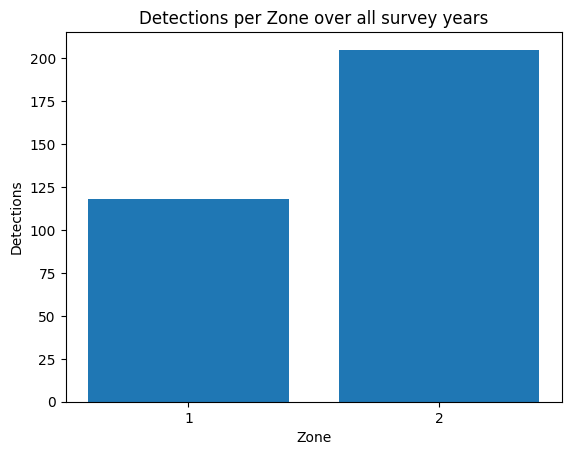

In [27]:
plt.bar(dtx_by_loc_yr["Zone"], height=dtx_by_loc_yr["Detections"])
plt.ylabel("Detections")
plt.xticks([1,2])
plt.xlabel("Zone")
plt.title("Detections per Zone over all survey years")
plt.show()

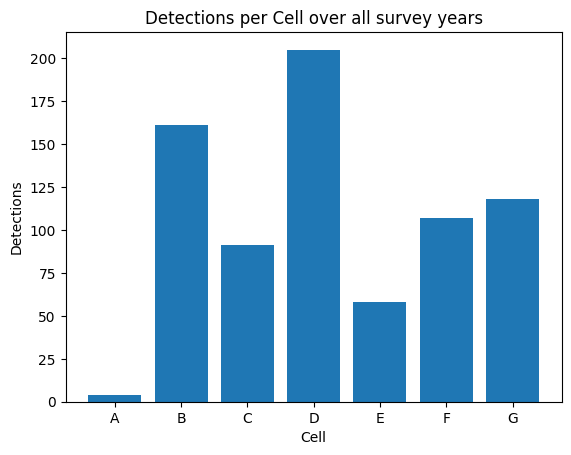

In [28]:
plt.bar(dtx_by_loc_yr["Cell"], height=dtx_by_loc_yr["Detections"])
plt.ylabel("Detections")
plt.xlabel("Cell")
plt.title("Detections per Cell over all survey years")
plt.show()

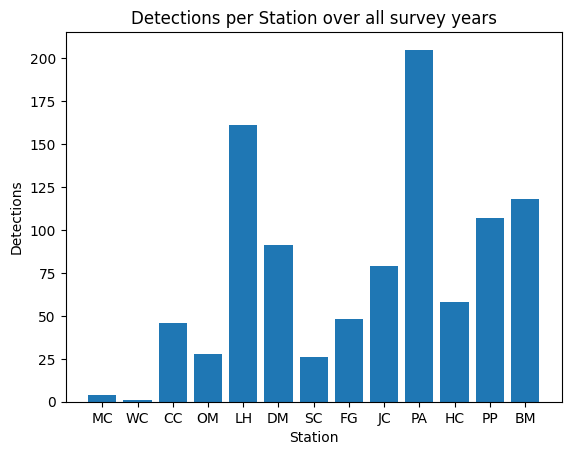

In [29]:
plt.bar(dtx_by_loc_yr["Station"], height=dtx_by_loc_yr["Detections"])
plt.ylabel("Detections")
plt.xlabel("Station")
plt.title("Detections per Station over all survey years")
plt.show()

# Detections over the landscape / stations and by year

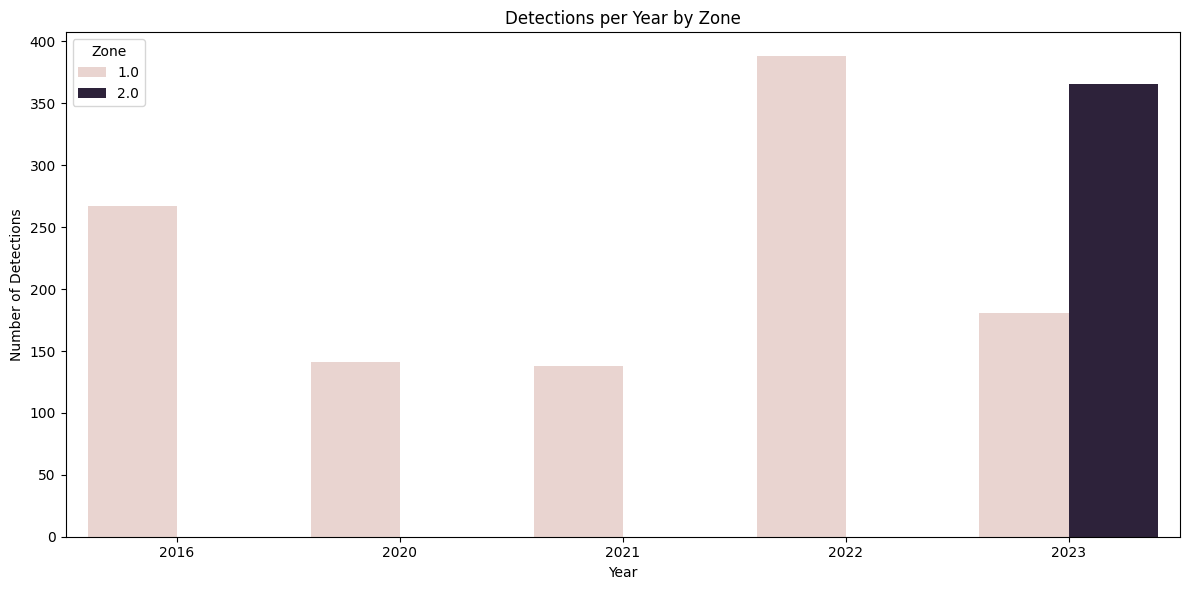

In [30]:
# plot detections found at each zone by year
# group data for plotting
data_zone_yr = dtx_by_loc_yr.groupby(["Zone", "Year"])["Detections"].sum().reset_index()

# Plot details
plt.figure(figsize=(12,6))
sns.barplot(data=data_zone_yr, x="Year", y="Detections", hue="Zone", dodge=True)
plt.title("Detections per Year by Zone")
plt.ylabel("Number of Detections")
plt.xlabel("Year")
plt.legend(title="Zone")
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

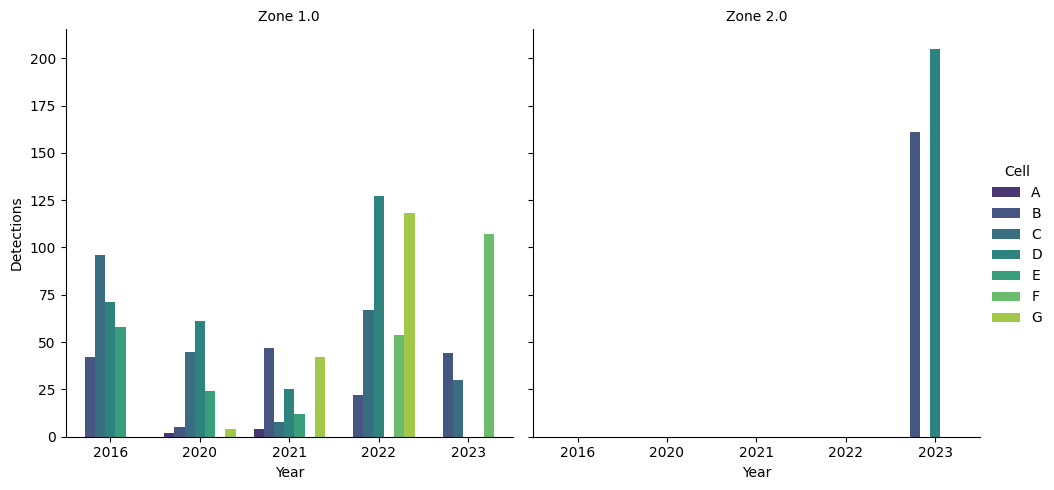

In [31]:
# plot detections found at each zone and cell by year
# group data for plotting
data_zone_cell_yr = dtx_by_loc_yr.groupby(["Zone", "Cell", "Year"])["Detections"].sum().reset_index()
# Get alphabetical order of Cells
cell_order = sorted(data_zone_cell_yr["Cell"].unique())

# Plot details
plt.figure(figsize=(12,6))
ax = sns.catplot(
    data=data_zone_cell_yr, kind="bar",
    x="Year", y="Detections", hue="Cell",
    hue_order=cell_order,
    col="Zone", dodge=True,
    palette="viridis"
)

ax.set_titles("Zone {col_name}")
ax.set_axis_labels("Year","Detections")
ax._legend.set_title("Cell")
# plt.tight_layout()
plt.show()

<Figure size 2000x1000 with 0 Axes>

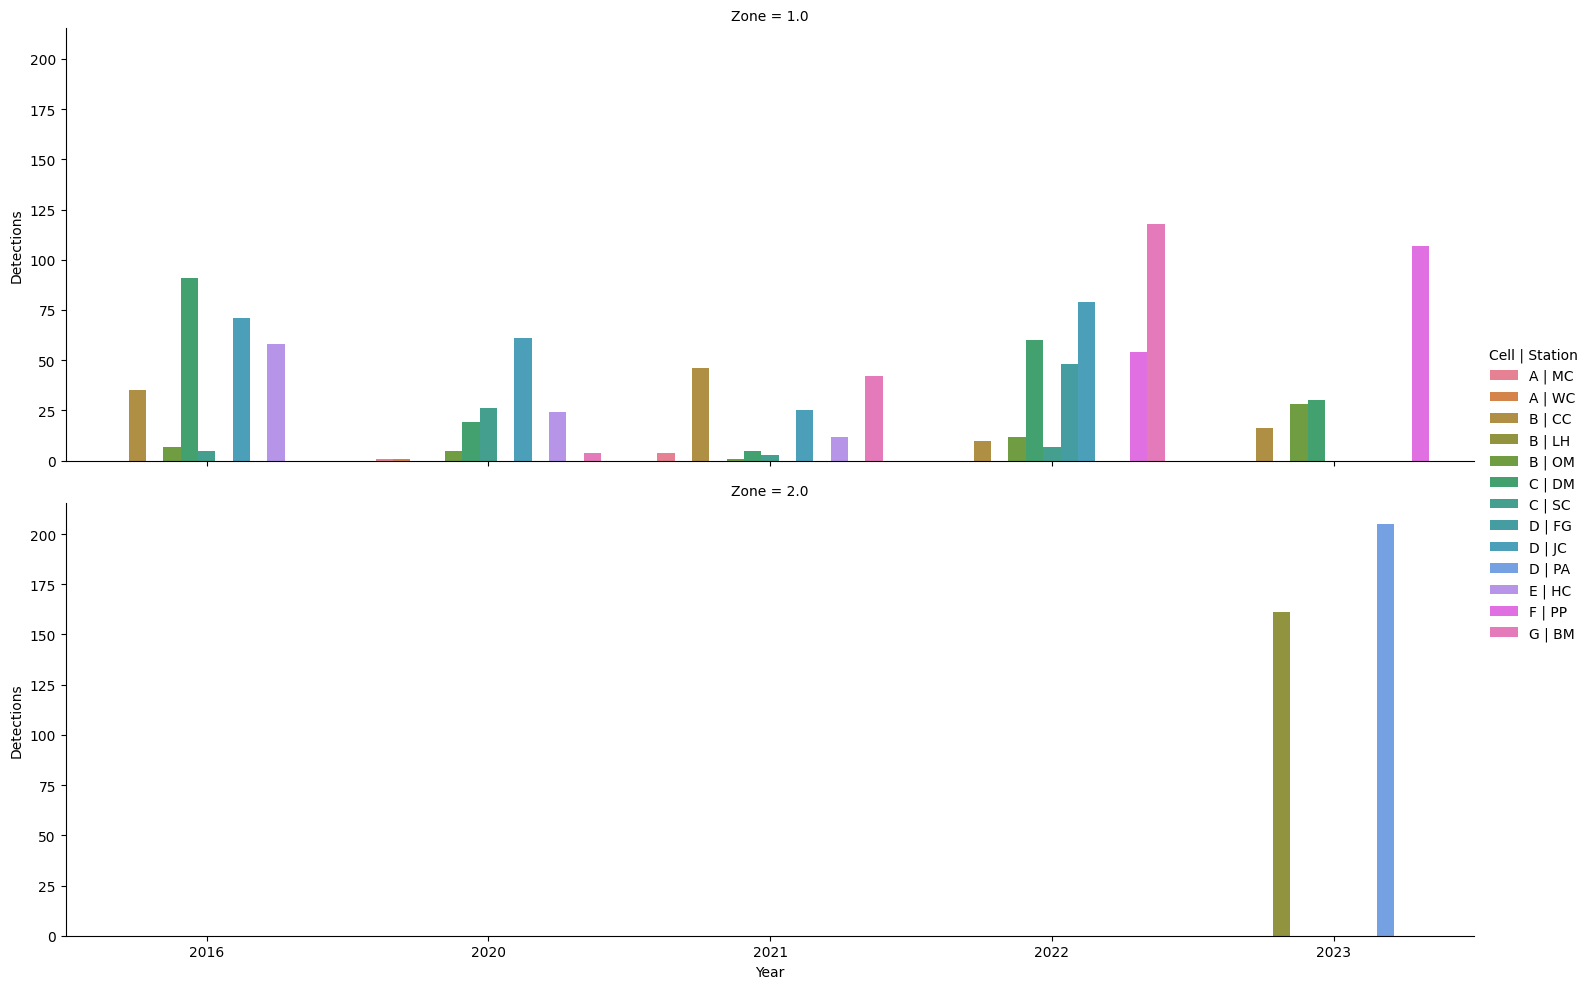

In [46]:
# Create nested label as new column: "Cell | Station"
dtx_by_loc_yr["Cell_Station"] = dtx_by_loc_yr["Cell"] + " | " + dtx_by_loc_yr["Station"]

# Order of hues in legend: sort by Cell first, then Station within Cell
nested_order = (
    dtx_by_loc_yr.groupby(["Cell", "Station"])
    .size()
    .reset_index()[["Cell", "Station"]]
    .sort_values(["Cell", "Station"])
)
nested_order = (nested_order["Cell"] + " | " + nested_order["Station"]).tolist()

# Plot details
plt.figure(figsize=(20,10))
ax2 = sns.catplot(
    data=dtx_by_loc_yr, kind="bar",
    x="Year", y="Detections", hue="Cell_Station",
    col="Zone", dodge=True,
    hue_order=nested_order,
    col_wrap=1,     # have 1 plot per column
    aspect=(3)      # width to height ratio
)

ax2.set_axis_labels("Year", "Detections")
ax2._legend.set_title("Cell | Station")
plt.show()


Each Zone is a separate National Forest in Montana. Each Cell is a 5 mile by 5 mile survey grid usually containing multiple bait stations.

From the plots above, it is clear that Zone 1 was the primary survey area. Zone 2 was only surveyed in 2023 using 2 stations. However, each Zone 2 station had many more detections of wolverines than any individual site in Zone 1. This begs the question, are wolverines more abundant in Zone 2 than Zone 1? More monitoring is required to answer this question.

For Zone 1, 2016 and 2022 were the years with the most detections. This trend is the result of several stations gathering higher detections, in contrast to the lower detection years, when most stations gathered fewer detections. The disparity between station detections counts suggests that if there was a wolverine in the area, it either visited the station consistently or hardly at all. A few stations have consistently high detections, potentially pointing to a resident wolverine: LH, OM, JC, and PP (2022-2023).

To note: are these discrepancies due to stations being dropped and added from year to year? Let's look with a heatmap!

# Bait Station Deployment/Usage by year

In [47]:
dtx_by_loc_yr[["Year","Station"]].head(10)

,Year,Station
0,2020,MC
1,2021,MC
2,2020,WC
3,2016,CC
4,2021,CC
5,2022,CC
6,2023,CC
7,2016,OM
8,2020,OM
9,2021,OM


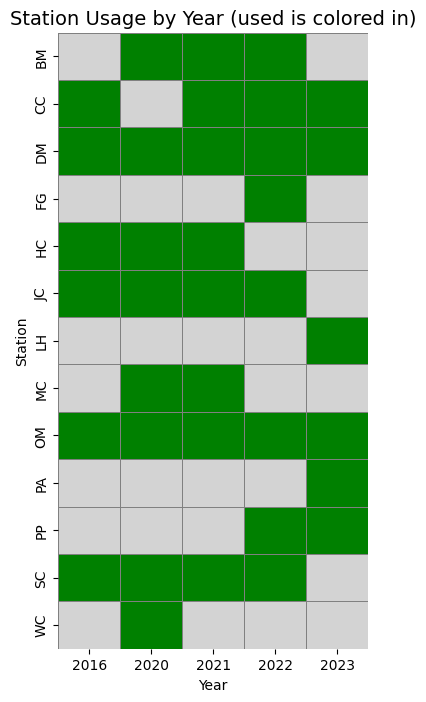

In [34]:
# create grid heatmap of which bait stations were used in a given year.

# add binary column for whether the station was used that year. all entries are
# 1 since all rows display used stations.
dtx_by_loc_yr["StationUsed"] = 1

# create a pivot table of Stations VS Years. Sort by station name then year.
data_stn_yrly = dtx_by_loc_yr.pivot_table(index="Station",
                                          columns="Year",
                                          values="StationUsed",
                                          fill_value=0)
data_stn_yrly = data_stn_yrly.sort_index().sort_index(axis=1)

# plot heatmap
plt.figure(figsize=(4,8))
ax3 = sns.heatmap(data_stn_yrly,
            cmap=["lightgray", "green"],
            cbar=False,
            linewidths=0.5,
            linecolor="gray")

plt.title("Station Usage by Year (used is colored in)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Station")
plt.show()

This heatmap surprised me. I was not expecting so much variation in bait station use from year to year. This explains the zero detection bars for some stations in the above plots, as many of those stations simply weren't operating in the zero detections years.

This is incredibly important for analyzing the data, since getting zero detections is a red flag and means the station was ineffective at gathering information on wolverine presence. Low detections in a prior year may impact whether the station is decomissioned and a new location determined to make the best use of limited research funds.

To find natal wolverine dens, we will need to focus on high-detection stations with a priority on long-term stations since female wolverines reuse natal dens. Stations with consistently higher detection rates may be near a natal wolverine den.

# Detections per individual

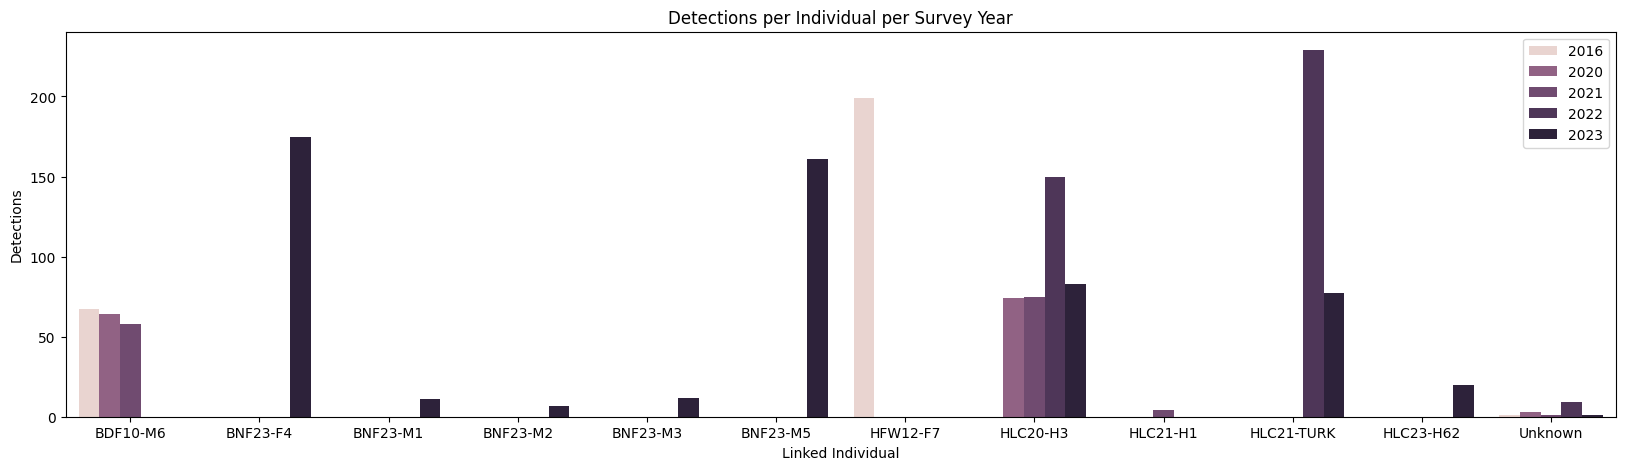

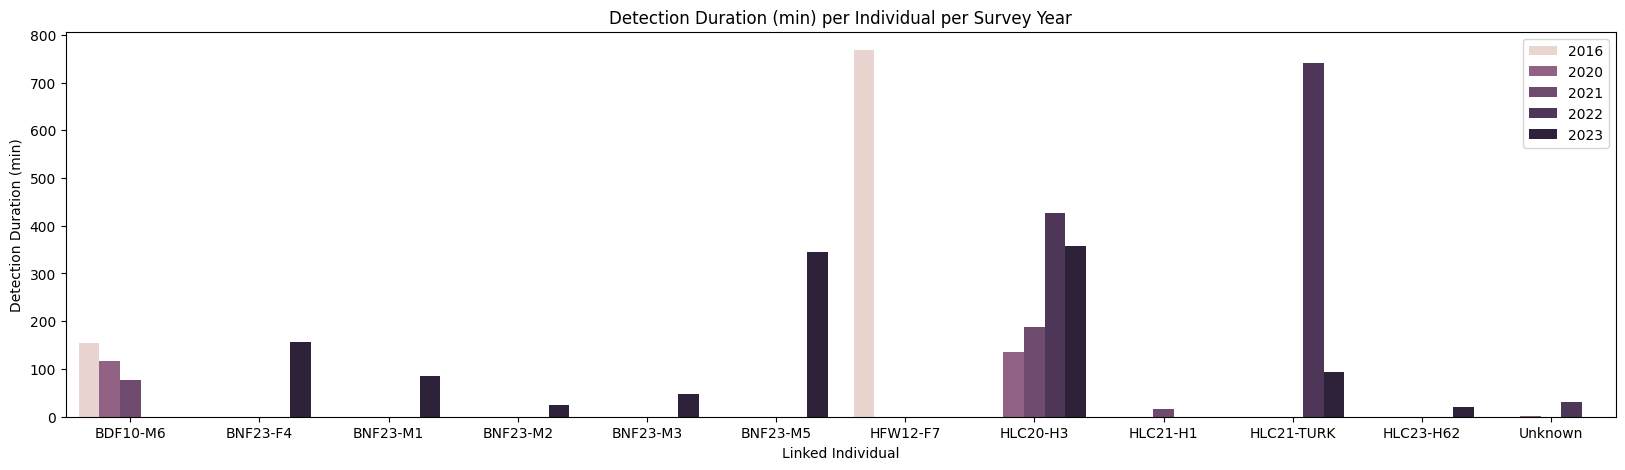

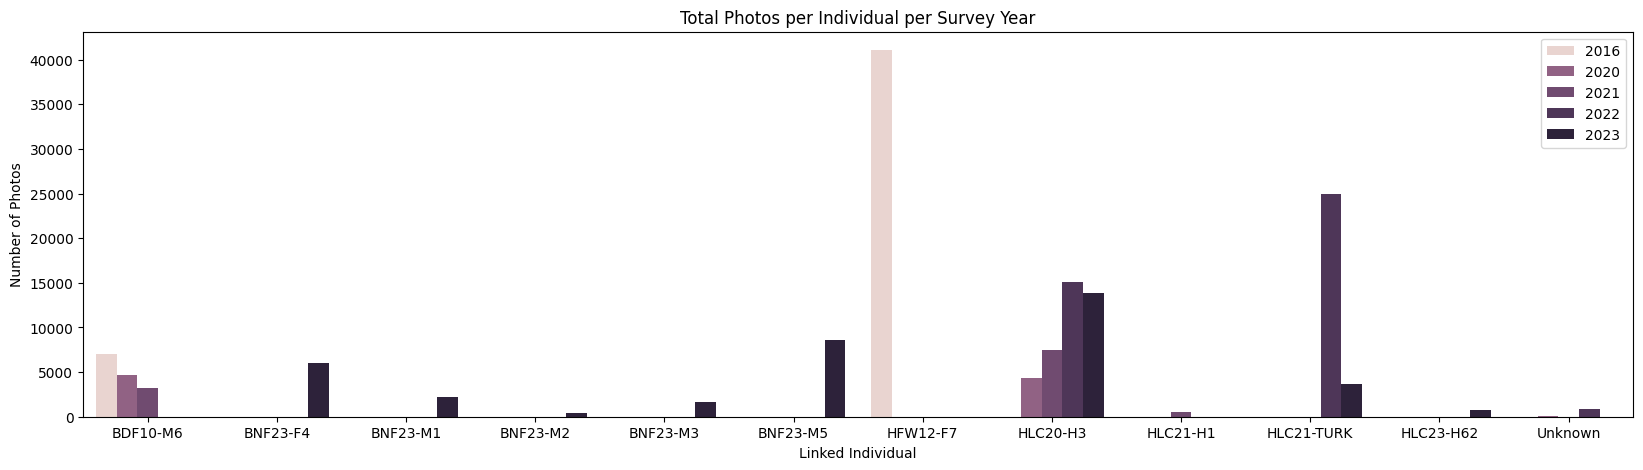

In [88]:
# ----------- number of detections -------------
# group data for plotting individual wolverines' detections by year
dtx_indiv_yr = data.groupby(["Linked Individual", "Year"]).size().reset_index(name="Detections")

# plot details
plt.figure(figsize=(20,5))
sns.barplot(data=dtx_indiv_yr,
            x="Linked Individual",
            y="Detections",
            hue="Year",
            dodge=True,
            )
plt.title("Detections per Individual per Survey Year")
plt.legend()
plt.show()
print("\n")

# ----------  duration detected ----------------
# print(data["Duration (minutes)"])     # min is 1 minute
# print(data["Duration (minutes).1"])   # min is 0 minutes, use this one

# group data for plotting individual wolverines' total minutes detected by year
dur_indiv_yr = data.groupby(["Linked Individual", "Year"])["Duration (minutes).1"].sum().reset_index(name="Duration")

# plot details
plt.figure(figsize=(20,5))
sns.barplot(data=dur_indiv_yr,
            x="Linked Individual",
            y="Duration",
            hue="Year",
            dodge=True,
            )
plt.title("Detection Duration (min) per Individual per Survey Year")
plt.ylabel("Detection Duration (min)")
plt.legend()
plt.show()
print("\n")

# ---------- Number of photos -----------------
# group data for plotting individual wolverines' total photos by year
dur_indiv_yr = data.groupby(["Linked Individual", "Year"])["No. photos"].sum().reset_index(name="nphotos")

# plot details
plt.figure(figsize=(20,5))
sns.barplot(data=dur_indiv_yr,
            x="Linked Individual",
            y="nphotos",
            hue="Year",
            dodge=True,
            )
plt.title("Total Photos per Individual per Survey Year")
plt.ylabel("Number of Photos")
plt.legend()
plt.show()

/tmp/ipython-input-193692571.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


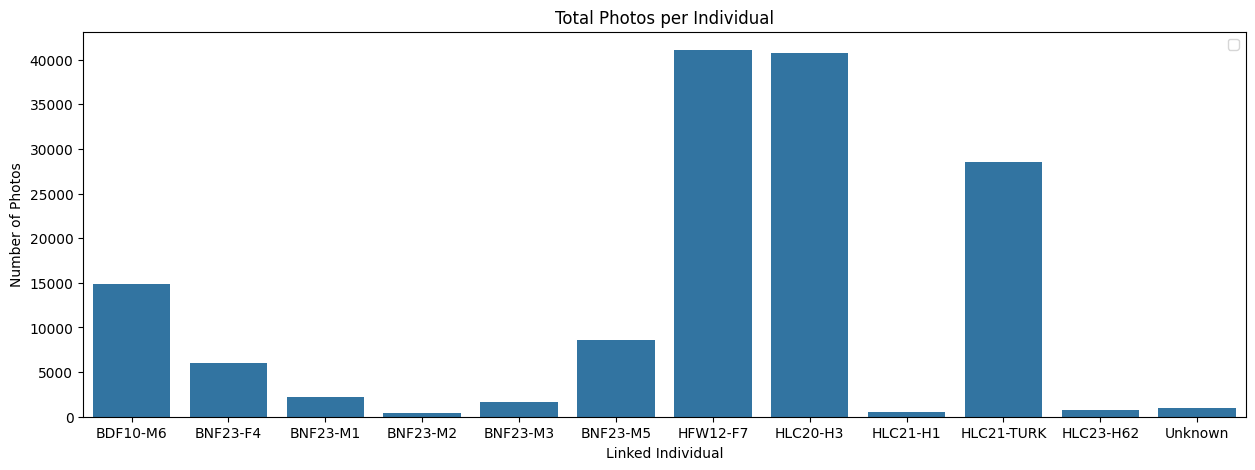

In [93]:
# ---------- Number of photos -----------------
# group data for plotting individual wolverines' total photos by year
dur_indiv_yr = data.groupby(["Linked Individual"])["No. photos"].sum().reset_index(name="nphotos")

# plot details
plt.figure(figsize=(15,5))
sns.barplot(data=dur_indiv_yr,
            x="Linked Individual",
            y="nphotos",
            dodge=True,
            )
plt.title("Total Photos per Individual")
plt.ylabel("Number of Photos")
plt.legend()
plt.show()

A detection in this dataset is defined as a set of camera trap images triggered at least 60 seconds apart from the next image. The definition of a detection varies according to the context of the research project. The detection histories of each individual animal are used to inform and estimate population abundance, density, and distribution across a landscape using ecological statistical models.

Visualizing the number of detections per individual and duration detected informs our understanding of which animals are data-rich. Data-rich individuals may be suitable to testing existing image classification machine learning models' ability to identify and classify individual wolverines from their unique ventral pelage patterns. This is one objective of my undergraduate thesis. Integrating machine learning into data processing would drastically reduce monitoring costs and potentially increase data accuracy.

This data shows that per individual, the number of detections, duration detected, and number of photos appear strongly correlated, yet have some potentially key differences. The number of detections does not faithfully predict the detection duration or number of photos, which may suggest a reevaluation of the project's definition of a detection.

Six out of eleven identified individual wolverines only appeared for one year of surveying, and that was usually in 2023, suggesting they were present in Zone 2, which was only surveyed in 2023. By contrast, HLC20-H3 was consistently detected for four successive years, BDF10-M6 for three years, and HLC21-TURK for two years.

These three wolverines and HFW12-F7 have the most photos available. The three aforementioned wolverines's data is suitable to training a machine learning model due to the variance in environment over the years, which would create a more robust training/testing dataset. HFW12-F7 was only detected during one year and may not be as robust of a dataset.

# Summary
My undergraduate thesis has 3 objectives:

1.   Assess the feasibility and performance of employing existing machine learning tools to identify individual wolverines from camera trap images using unique pelage patterns.
2.   Identify high detectability areas for wolverines in the survey areas using statistical models to guide population surveys.
3.   Utilize drones to non-invasively, ethically, and safely detect wolverine natal dens.

### Detections over the landscape and by bait stations
Identifying the nested survey system of zones containing cells that contained multiple bait stations revealed that Zone 1 was the primary survey area, with many stations in place for the years of 2016 and 2020 through 2023. Zone 2 was surveyed using 2 bait stations in 2023 alone. 2022 was a high detection year. Stations PA and LH in Zone 2 had the most detections (surpassing 150 detections) in their one survey year than any other station had over multiple years.

### Station Deployment / Usage
Some stations had zero detections, raising the question of whether or not each station was used across all years. Only station DM (Zone 1) was surveyed over all 5 years. The heatmap of bait station deployments by year reveals that station deployment varies wildly, which should be taken into consideration when stations appear with zero detections. Zero detections may mean the station was deployed and no wolverines were detected, or it may mean that the station was not deployed that year.

### Detections per Individual
These plots showed how many detections, total duration detected, and number of photos for each individual wolverine detected over the 5 survey years. This information helped isolate 4 data-rich individuals that would be ideal for training and testing existing machine learning models to identify individual wolverines from their unique ventral pelage patterns.


